In [44]:
import pandas as pd

In [45]:
import os
os.chdir(r"C:\Users\sneha\Downloads\netflix_titles.csv")
print(os.getcwd())

C:\Users\sneha\Downloads\netflix_titles.csv


In [46]:
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [48]:
df.shape

(8807, 12)

In [49]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [52]:
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()
df['type'] = df['type'].str.strip()
     

In [53]:
df['country'].unique()
df['rating'].unique()
df['type'].unique()
     

array(['Movie', 'TV Show'], dtype=object)

In [54]:
df['country'].value_counts().head(10)
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [55]:
df['country'] = df['country'].str.title()
df['rating'] = df['rating'].str.upper()

In [56]:
if df['date_added'].dtype == 'object':
    df['date_added'] = pd.to_datetime(
        df['date_added'].str.strip(),
        format='%B %d, %Y'
    )

In [57]:
df['release_year'] = pd.to_datetime(
    df['release_year'].astype(str) + '-01-01'
)

#### Normalization of categorical feature means:- Removing inconsistencies , Standardizing format , Splitting multiple values properly , Ensuring uniform category representation , Making categories ready for analysis and dashboards.

In [58]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [59]:
# 1. The "Unknown" Method: For names where guessing is impossible
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [60]:
# 2. The "Mode" (Most Frequent) Method: For categories with a clear majority
most_common_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(most_common_country)

most_common_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(most_common_rating)


In [61]:
# 3. The "Drop" Method: For tiny amounts of missing data where filling is risky
# We are dropping the rows where 'date_added' or 'duration' are missing (only ~13 rows total)
df = df.dropna(subset=['date_added', 'duration'])

# Final check to prove all nulls are handled!
print("Null values remaining after targeted cleaning:")
print(df.isnull().sum())

Null values remaining after targeted cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [62]:
print(f"Final Shape: {df.shape}")
print(f"\nNull Values:\n{df.isnull().sum()}")
df.head()
     

Final Shape: (8794, 12)

Null Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021-01-01,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021-01-01,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [63]:
cat_columns = ['type','title','director','cast','country','rating','listed_in']

for col in cat_columns:
    df[col] = df[col].astype(str).str.strip()

In [64]:
for col in cat_columns:
    df[col] = df[col].str.lower()

In [65]:
df['listed_in'] = df['listed_in'].str.replace(", ", ",")
df['listed_in'] = df['listed_in'].str.split(",")

In [66]:
df['country'] = df['country'].str.replace(", ", ",")
df['country'] = df['country'].str.split(",")

In [67]:
df['rating'] = df['rating'].str.lower()

In [68]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ","_")

In [69]:
df['duration'] = df['duration'].str.extract('(\d+)').astype(float)

In [70]:
df['release_year'] = pd.to_datetime(df['release_year'], unit='ns')

In [71]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,movie,dick johnson is dead,kirsten johnson,unknown,[united states],2021-09-25,2020-01-01,pg-13,90.0,[documentaries],"As her father nears the end of his life, filmm..."
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",[south africa],2021-09-24,2021-01-01,tv-ma,2.0,"[international tv shows, tv dramas, tv mysteries]","After crossing paths at a party, a Cape Town t..."
2,s3,tv show,ganglands,julien leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",[united states],2021-09-24,2021-01-01,tv-ma,1.0,"[crime tv shows, international tv shows, tv ac...",To protect his family from a powerful drug lor...
3,s4,tv show,jailbirds new orleans,unknown,unknown,[united states],2021-09-24,2021-01-01,tv-ma,1.0,"[docuseries, reality tv]","Feuds, flirtations and toilet talk go down amo..."
4,s5,tv show,kota factory,unknown,"mayur more, jitendra kumar, ranjan raj, alam k...",[india],2021-09-24,2021-01-01,tv-ma,2.0,"[international tv shows, romantic tv shows, tv...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,movie,zodiac,david fincher,"mark ruffalo, jake gyllenhaal, robert downey j...",[united states],2019-11-20,2007-01-01,r,158.0,"[cult movies, dramas, thrillers]","A political cartoonist, a crime reporter and a..."
8803,s8804,tv show,zombie dumb,unknown,unknown,[united states],2019-07-01,2018-01-01,tv-y7,2.0,"[kids' tv, korean tv shows, tv comedies]","While living alone in a spooky town, a young g..."
8804,s8805,movie,zombieland,ruben fleischer,"jesse eisenberg, woody harrelson, emma stone, ...",[united states],2019-11-01,2009-01-01,r,88.0,"[comedies, horror movies]",Looking to survive in a world taken over by zo...
8805,s8806,movie,zoom,peter hewitt,"tim allen, courteney cox, chevy chase, kate ma...",[united states],2020-01-11,2006-01-01,pg,88.0,"[children & family movies, comedies]","Dragged from civilian life, a former superhero..."


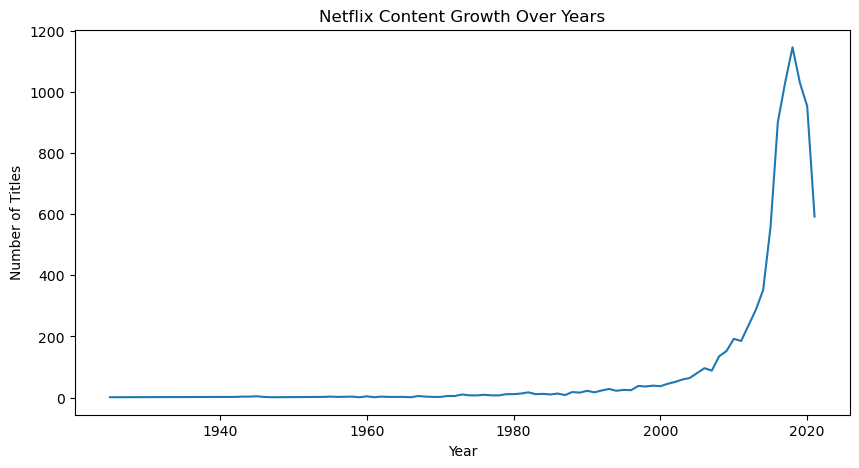

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

content_growth = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.lineplot(
x=content_growth.index,
y=content_growth.values
)

plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

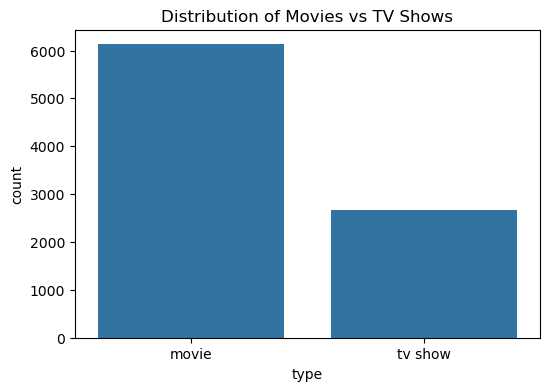

In [73]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Distribution of Movies vs TV Shows")

plt.show()

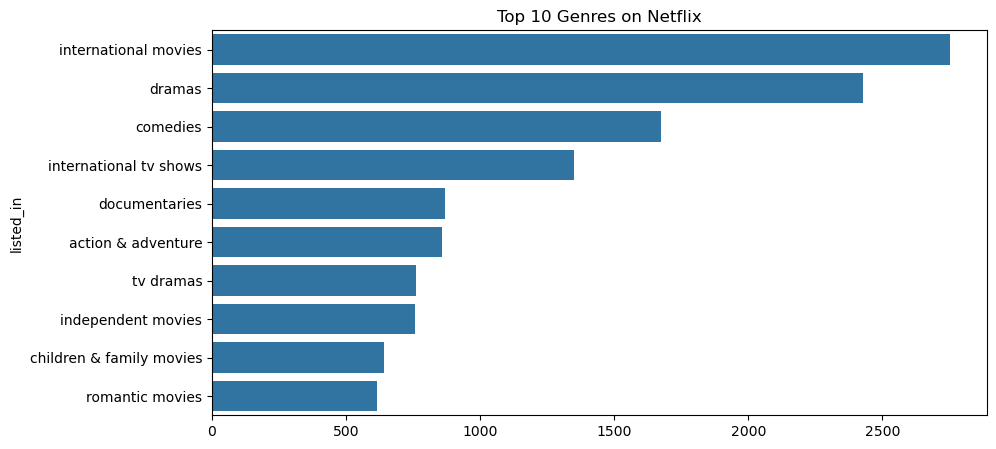

In [74]:
df_genre = df.explode('listed_in')

top_genres = df_genre['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
x=top_genres.values,
y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")

plt.show()

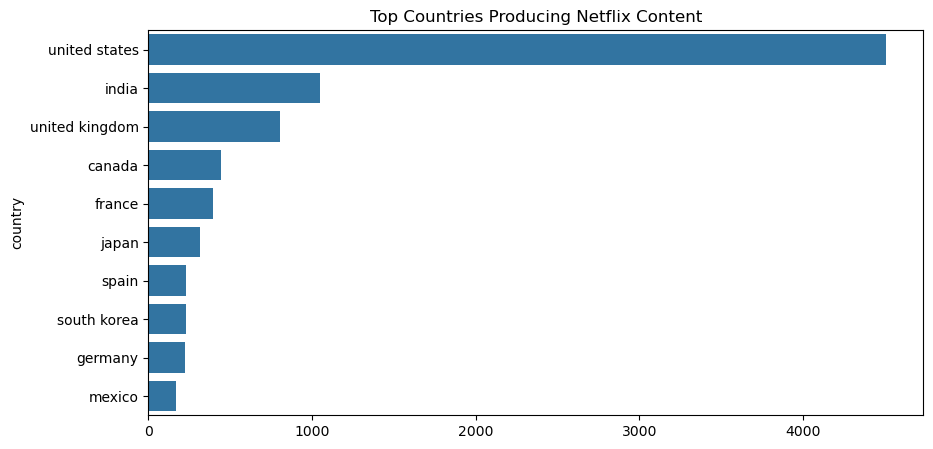

In [75]:
df_country = df.explode('country')

top_countries = df_country['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
x=top_countries.values,
y=top_countries.index
)

plt.title("Top Countries Producing Netflix Content")

plt.show()

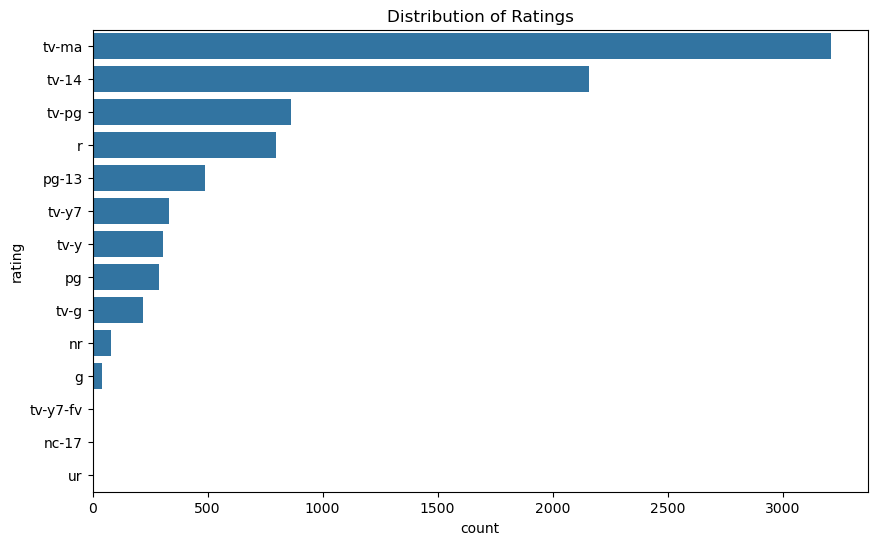

In [76]:
plt.figure(figsize=(10,6))

sns.countplot(
y='rating',
data=df,
order=df['rating'].value_counts().index
)

plt.title("Distribution of Ratings")

plt.show()

In [77]:
def categorize_duration(x):

    if x < 60:
        return "short"

    elif x <= 120:
        return "medium"

    else:
        return "long"

df['content_length_category'] = df['duration'].apply(categorize_duration)

In [78]:
df['content_length_category'].value_counts()

content_length_category
medium    4528
short     3124
long      1142
Name: count, dtype: int64

In [79]:
df['year_added'] = df['date_added'].dt.year

def determine_originality(row):

    if pd.isna(row['year_added']):
        return 'Unknown'
    if row['release_year'].year == row['year_added']:
        return 'Original'
    else:
        return 'Licensed'

df['original_vs_licensed'] = df.apply(determine_originality, axis=1)

print(df['original_vs_licensed'].value_counts())


original_vs_licensed
Licensed    5554
Original    3240
Name: count, dtype: int64


In [80]:
df_ml = df.copy()

df_ml['genre'] = df_ml['listed_in'].apply(lambda x: x[0] if isinstance(x,list) else x)

In [81]:
from sklearn.preprocessing import LabelEncoder

le_genre = LabelEncoder()

df_ml['genre_encoded'] = le_genre.fit_transform(df_ml['genre'])

In [82]:
le_rating = LabelEncoder()

df_ml['rating_encoded'] = le_rating.fit_transform(df_ml['rating'])

In [83]:
X = df_ml[['duration','rating_encoded','genre_encoded']]

In [84]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df_ml['cluster'] = kmeans.fit_predict(X)

In [85]:
df_ml['cluster'].value_counts()

cluster
1    4081
0    2919
2    1794
Name: count, dtype: int64

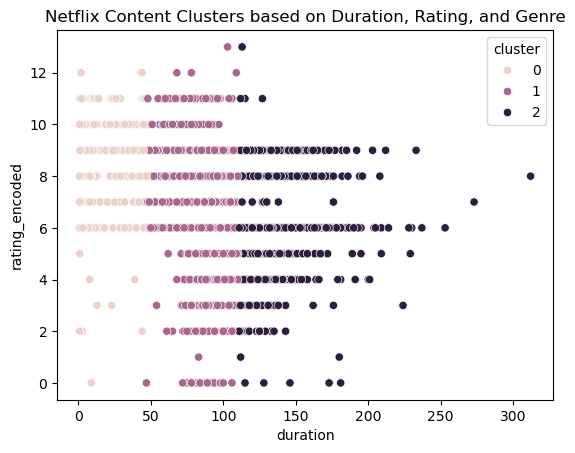

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
x=df_ml['duration'],
y=df_ml['rating_encoded'],
hue=df_ml['cluster']
)

plt.title("Netflix Content Clusters based on Duration, Rating, and Genre")

plt.show()